<a href="https://colab.research.google.com/github/LujainAldujain/Data_Mining_Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phase 2: Data Summarization and Preprocessing**



###**Statistical Summary**

The statistical summary provides the count, mean, standard deviation, minimum, quartiles, and maximum values for the numerical attributes. It helps in understanding the distribution and spread of the data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
df[numeric_columns].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


### **Five-Number Summary**

The five-number summary includes the minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum values. These values help describe the distribution and range of each numerical attribute.

In [ ]:
df[numeric_columns].describe().loc[['min', '25%', '50%', '75%', 'max']]

,tenure,MonthlyCharges,TotalCharges
min,0.0,18.25,18.8000
25%,9.0,35.50,401.4500
50%,29.0,70.35,1397.4750
75%,55.0,89.85,3794.7375
max,72.0,118.75,8684.8000


### **Outlier Analysis**

The IQR method was used to identify potential outliers in the numerical attributes. Values below Q1 - 1.5(IQR) or above Q3 + 1.5(IQR) were considered potential outliers. Detecting these values helps determine whether further preprocessing may be needed.

In [ ]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Attribute:", column)
    print("Number of Outliers:", len(outliers))
    print("--------------------------")

Attribute: tenure
Number of Outliers: 0
--------------------------
Attribute: MonthlyCharges
Number of Outliers: 0
--------------------------
Attribute: TotalCharges
Number of Outliers: 0
--------------------------


##**Boxplot of tenure**
The boxplot of tenure shows the distribution of customer tenure. It provides a visual representation of the median, quartiles, spread, and any potential outliers.

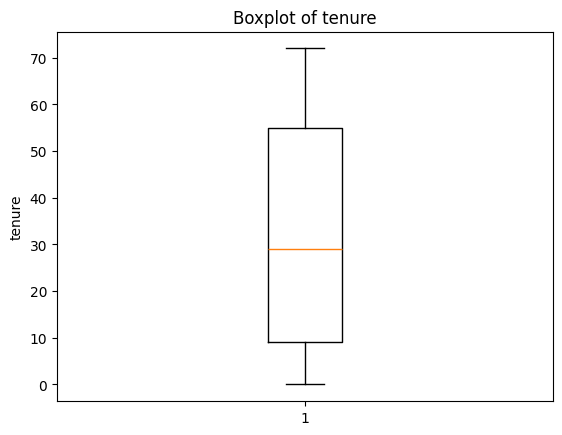

In [ ]:
plt.figure()
plt.boxplot(df['tenure'].dropna())
plt.title("Boxplot of tenure")
plt.ylabel("tenure")
plt.show()

##**Boxplot of MonthlyCharges**
The boxplot of MonthlyCharges shows the distribution of customers' monthly charges. It helps identify the spread of values and whether any observations fall outside the expected range.

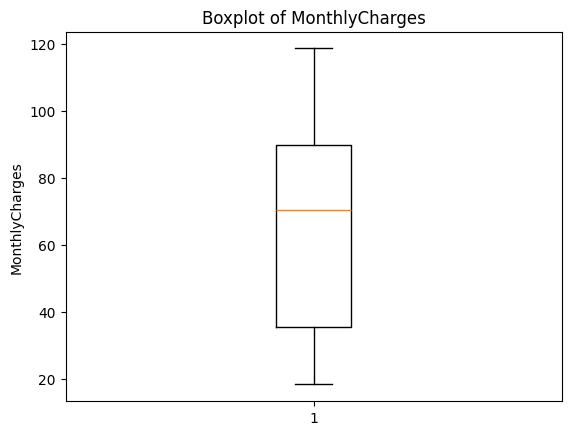

In [ ]:
plt.figure()
plt.boxplot(df['MonthlyCharges'].dropna())
plt.title("Boxplot of MonthlyCharges")
plt.ylabel("MonthlyCharges")
plt.show()

##**Boxplot of TotalCharges**
The boxplot of TotalCharges shows the distribution of the total amount charged to customers. It helps visualize the median, variability, and potential extreme values in this attribute.

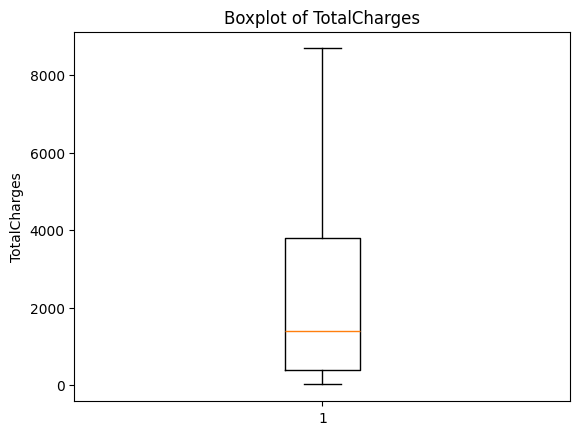

In [ ]:
plt.figure()
plt.boxplot(df['TotalCharges'].dropna())
plt.title("Boxplot of TotalCharges")
plt.ylabel("TotalCharges")
plt.show()

### **Numerical Data Analysis**

The five-number summary, IQR method, and boxplots were used to analyze the numerical attributes.

These techniques provide information about the center, spread, and possible extreme values in the dataset. The results can help determine whether some numerical attributes require preprocessing before applying data mining techniques.

No outliers were removed in this section because this part focuses only on analyzing the data. Any necessary treatment will be performed during the preprocessing stage.

#**Missing Values Analysis**


Missing Values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


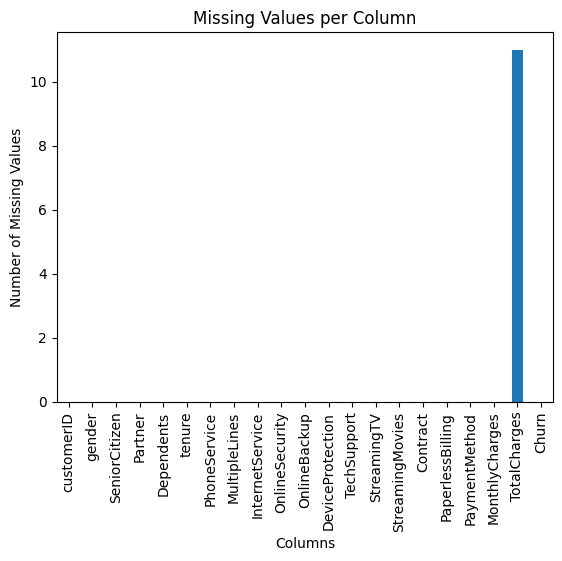

In [ ]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()
print("\nMissing Values:")
print(missing)

plt.figure()
missing.plot(kind='bar')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

The missing values analysis shows that the majority of columns in the dataset are complete, with no missing values detected. However, the `TotalCharges` column contains 11 missing (NaN) values, as shown in both the printed summary and the bar chart above. Since this affects less than 0.2% of the total records, it is unlikely to significantly impact the overall analysis, but the affected rows still require further investigation to understand why the data is missing before deciding how to handle them.

In [ ]:
missing_charges = df[df['TotalCharges'].isnull()]
print(f"Rows with missing TotalCharges: {len(missing_charges)}")
missing_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Rows with missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


All 11 of these rows correspond to customers with `tenure = 0`, meaning they have not yet completed a single billing cycle. This strongly suggests these are newly signed-up customers who joined the service but had not been charged at the time the data was collected, rather than an error in data entry or a technical fault.